# Linear regression

A common empirical relationship is that concrete compressive strength decreases as the water-cement ratio increases.

In this notebook, we will simulate experimental lab data of the form:

- $x$ = water-cement ratio  
- $y$ = compressive strength (MPa)

Assuming a linear ground-truth trend $y = 15 - 8x + \text{noise}$, we will estimate this relationship from noisy observations.

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

### Simulated laboratory data ($x$ vs $y$)

In [2]:
# Seed
np.random.seed(0)
# Number of data points
N = 20

# Random generation of water-cement ratio
X = 0.2 + 0.4 * np.random.rand(N, 1)

# True relationship: strength decreases with higher water content (simplified linear model)
true_params = np.array([15, -8]) # Intercept, slope
y = true_params[0] + true_params[1] * X[:, 0]
# Noisy observation
y += 0.5*np.random.randn(N)

### We estimate the relationship between water-cement ratio (input) and concrete compressive strength (output) using ordinary least squares linear regression

In [3]:
# Build the design matrix adding the bias term (intercept column of ones)
X_design = np.hstack([np.ones((N, 1)), X])

In [4]:
# Closed-form least squares solution
beta = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y

print("Estimated parameters (intercept, slope):", beta)
print("True parameters (intercept, slope):", true_params)

Estimated parameters (intercept, slope): [14.49741758 -6.83136092]
True parameters (intercept, slope): [15 -8]


### Prediction for new data

In [5]:
# Prediction strength curve
X_test = np.linspace(0.2, 0.6, 100).reshape(-1, 1)
X_test_design = np.hstack([np.ones((100, 1)), X_test])

y_pred = X_test_design @ beta
y_true = X_test_design @ true_params

### Visualization 

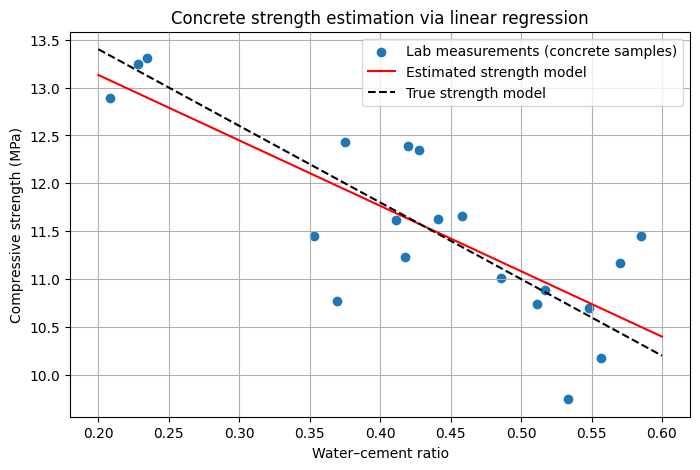

In [6]:
plt.figure(figsize=(8, 5))

plt.scatter(X, y, label="Lab measurements (concrete samples)")
plt.plot(X_test, y_pred, label="Estimated strength model", color="red")
plt.plot(X_test, y_true, label="True strength model", color="black", linestyle="dashed")

plt.xlabel("Water–cement ratio")
plt.ylabel("Compressive strength (MPa)")
plt.title("Concrete strength estimation via linear regression")
plt.legend()
plt.grid(True)
plt.show()